# 2025-26 Premier League Model — Post-Mortem

Walk-forward evaluation of the non-penalty Bayesian model across the full season.
The model is re-fit on all data available **before** each round, then predicts
that round's actual fixtures.

**Primary lens: xG.** Goals carry a large Poisson random component; xG measures
the quality of chances created and is the underlying signal the model is
actually trying to predict. A model that tracks xG well but goals loosely is
doing its job correctly — the gap is noise, not error.

**A note on "rounds":** the x-axis below is labelled *Round*, not *Gameweek*.
Predictions are pulled in chronological batches, and several of those batches
are **not** full 10-match gameweeks — postponed and rearranged fixtures get
pulled on their own, so some rounds contain as few as 1–3 matches. Treating
them as gameweeks would be misleading, so they're just numbered rounds.

Sections:
1. Overall picture — MAE, calibration, home/away bias (goals & xG)
2. Accuracy over time, by round (goals & xG)
3. Team-by-team — who's over/under-predicted (goals & xG)
4. Shrinkage analysis (goals & xG)

In [17]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.stats import spearmanr

_here = Path.cwd()
if not (_here / 'postmortem_2526.ipynb').exists():
    for _c in [_here / 'premier_league',
               _here / 'non_penalty_bayes' / 'premier_league',
               _here / 'team_strength' / 'non_penalty_bayes' / 'premier_league']:
        if _c.exists():
            os.chdir(_c)
            break

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT    = str(NOTEBOOK_DIR.parents[4])
DB_PATH      = os.path.join(REPO_ROOT, 'infra', 'data', 'db', 'fotmob.db')
OUT_DIR      = NOTEBOOK_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

SEASON = '2025-2026'
LEAGUE = 'Premier_League'

# ── shared palette (one system, used consistently across every chart) ──────
C_XG        = '#2a78d6'   # xG series (categorical slot 1 / diverging "under" pole)
C_GOALS     = '#eb6834'   # goals series (categorical slot 2)
C_PRED      = '#1baf7a'   # predicted-as-its-own-series (categorical slot 3)
C_OVER      = '#e34948'   # over-prediction / positive bias / positive luck
C_UNDER     = '#2a78d6'   # under-prediction / negative bias / negative luck
C_GRID      = '#e1e0d9'
C_AXIS      = '#c3c2b7'
C_MUTED     = '#898781'
C_INK       = '#0b0b0b'
C_INK2      = '#52514e'

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.edgecolor': C_AXIS,
    'axes.labelcolor': C_INK,
    'text.color': C_INK,
    'xtick.color': C_INK2,
    'ytick.color': C_INK2,
    'axes.grid': True,
    'grid.color': C_GRID,
    'grid.linewidth': 0.8,
    'axes.axisbelow': True,
})

print(f'DB: {DB_PATH}')

DB: /Users/admin/dev/algobetting/infra/data/db/fotmob.db


In [18]:
conn = sqlite3.connect(DB_PATH)
match = pd.read_sql('''
    SELECT gw AS round, gw_start AS round_start, gw_end AS round_end,
           home_team, away_team,
           home_predicted, away_predicted,
           home_actual, away_actual,
           home_error, away_error,
           home_xg, away_xg,
           home_xg_error, away_xg_error
    FROM pl_match_predictions
    WHERE season = ? AND league = ?
    ORDER BY round, home_team
''', conn, params=[SEASON, LEAGUE])
conn.close()

# Goals-based bias
match['home_bias']    = match['home_predicted'] - match['home_actual']
match['away_bias']    = match['away_predicted'] - match['away_actual']
match['total_pred']   = match['home_predicted'] + match['away_predicted']
match['total_actual'] = match['home_actual']    + match['away_actual']
match['total_bias']   = match['total_pred']     - match['total_actual']

# xG-based bias. NOTE: home_xg_error/away_xg_error in the DB are stored as
# abs(pred - xg), not signed - confirmed by spot-checking rows where pred < xg
# but the stored error was still positive. Recompute signed bias directly.
match['home_xg_bias'] = match['home_predicted'] - match['home_xg']
match['away_xg_bias'] = match['away_predicted'] - match['away_xg']
match['total_xg']     = match['home_xg'] + match['away_xg']
match['total_xg_bias']= match['total_pred'] - match['total_xg']

# Luck = how much goals beat/missed xG (unforecastable Poisson noise)
match['home_luck']  = match['home_actual'] - match['home_xg']
match['away_luck']  = match['away_actual'] - match['away_xg']
match['total_luck'] = match['total_actual'] - match['total_xg']

n_rounds = match['round'].nunique()
print(f"Matches: {len(match)}   Rounds: {n_rounds}   xG coverage: {match['home_xg'].notna().sum()}/{len(match)}")
match.head(3)

Matches: 330   Rounds: 37   xG coverage: 330/330


,round,round_start,round_end,home_team,away_team,home_predicted,away_predicted,home_actual,away_actual,home_error,...,total_pred,total_actual,total_bias,home_xg_bias,away_xg_bias,total_xg,total_xg_bias,home_luck,away_luck,total_luck
0,6,2025-09-27,2025-09-29,Aston Villa,Fulham,1.262853,1.258696,3.0,1.0,1.737147,...,2.521550,4.0,-1.478450,0.152853,0.338696,2.03,0.491550,1.89,0.08,1.97
1,6,2025-09-27,2025-09-29,Brentford,Man United,1.506089,1.597407,3.0,1.0,1.493911,...,3.103496,4.0,-0.896504,-0.513911,-0.482593,4.10,-0.996504,0.98,-1.08,-0.10
2,6,2025-09-27,2025-09-29,Chelsea,Brighton,2.024583,1.219931,1.0,3.0,1.024583,...,3.244514,4.0,-0.755486,0.214583,-1.060069,4.09,-0.845486,-0.81,0.72,-0.09


## 1. Overall Picture — MAE, Calibration, Home/Away Bias

In [19]:
mae_goals = pd.concat([match['home_error'], match['away_error']]).abs().mean()
mae_xg    = pd.concat([match['home_xg_bias'].abs(), match['away_xg_bias'].abs()]).mean()
noise     = pd.concat([match['home_luck'].abs(), match['away_luck'].abs()]).mean()

pred_std_total  = match['total_pred'].std()
goals_std_total = match['total_actual'].std()
xg_std_total    = match['total_xg'].std()

overall = pd.DataFrame({
    'Metric': [
        'MAE — predicted vs goals (skill + luck)',
        'MAE — predicted vs xG (skill only)',
        'Irreducible noise  |goals − xG|',
        'MAE gap explained by noise',
        '',
        'Home bias vs goals  (pred − actual)',
        'Away bias vs goals  (pred − actual)',
        'Home bias vs xG     (pred − xG)',
        'Away bias vs xG     (pred − xG)',
        '',
        'Std dev — predicted total / game',
        'Std dev — actual goals total / game',
        'Std dev — actual xG total / game',
        'Compression ratio  (goals σ / pred σ)',
        'Compression ratio  (xG σ / pred σ)',
    ],
    'Value': [
        round(mae_goals, 4),
        round(mae_xg, 4),
        round(noise, 4),
        f'{(mae_goals - mae_xg) / mae_goals:.0%}',
        '',
        round(match['home_bias'].mean(), 4),
        round(match['away_bias'].mean(), 4),
        round(match['home_xg_bias'].mean(), 4),
        round(match['away_xg_bias'].mean(), 4),
        '',
        round(pred_std_total, 4),
        round(goals_std_total, 4),
        round(xg_std_total, 4),
        round(goals_std_total / pred_std_total, 2),
        round(xg_std_total / pred_std_total, 2),
    ]
})
print(overall.to_string(index=False))
overall

                                 Metric   Value
MAE — predicted vs goals (skill + luck)  0.8788
     MAE — predicted vs xG (skill only)  0.5695
        Irreducible noise  |goals − xG|  0.7899
             MAE gap explained by noise     35%
                                               
    Home bias vs goals  (pred − actual) -0.0467
    Away bias vs goals  (pred − actual)  0.0319
        Home bias vs xG     (pred − xG)  -0.068
        Away bias vs xG     (pred − xG)  0.0108
                                               
       Std dev — predicted total / game   0.274
    Std dev — actual goals total / game  1.5638
       Std dev — actual xG total / game  1.0082
  Compression ratio  (goals σ / pred σ)    5.71
     Compression ratio  (xG σ / pred σ)    3.68


,Metric,Value
0,MAE — predicted vs goals (skill + luck),0.8788
1,MAE — predicted vs xG (skill only),0.5695
2,Irreducible noise |goals − xG|,0.7899
3,MAE gap explained by noise,35%
4,,
5,Home bias vs goals (pred − actual),-0.0467
6,Away bias vs goals (pred − actual),0.0319
7,Home bias vs xG (pred − xG),-0.068
8,Away bias vs xG (pred − xG),0.0108
9,,


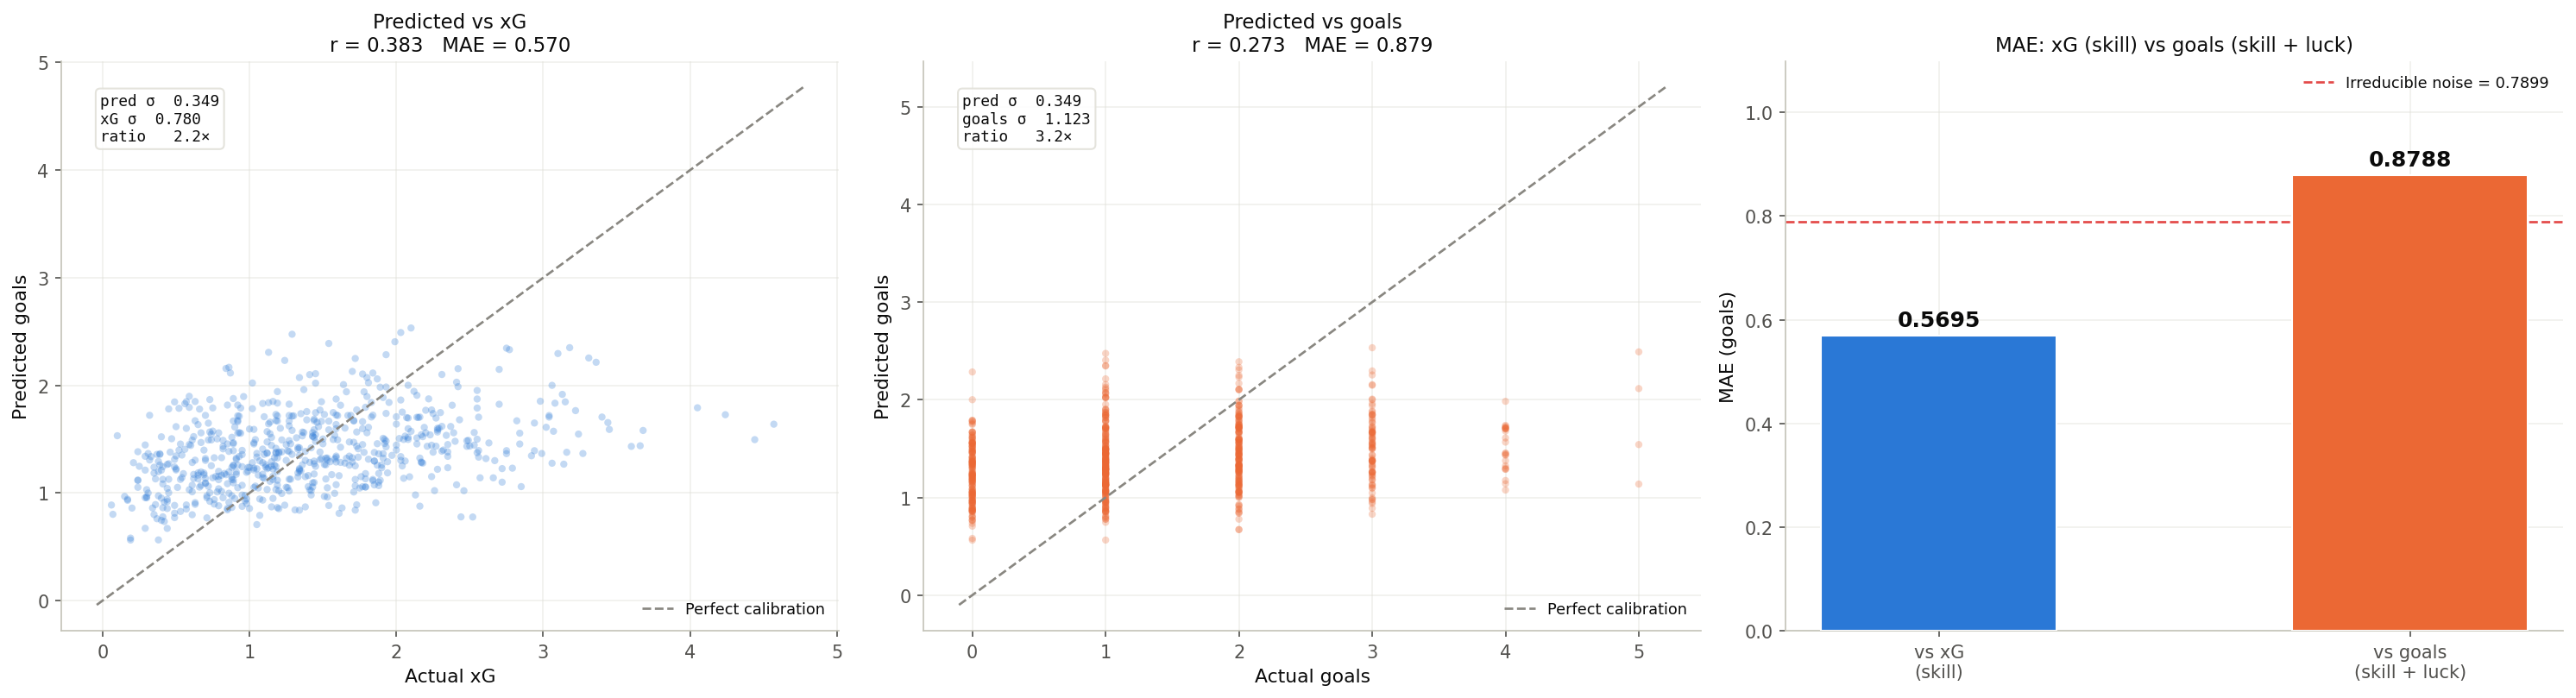

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

all_pred  = pd.concat([match['home_predicted'], match['away_predicted']])
all_xg    = pd.concat([match['home_xg'],        match['away_xg']])
all_goals = pd.concat([match['home_actual'],    match['away_actual']])

def cal_scatter(ax, pred, bench, label, color):
    ax.scatter(bench, pred, alpha=0.28, s=16, color=color, edgecolors='none')
    lo = min(bench.min(), pred.min()) - 0.1
    hi = max(bench.max(), pred.max()) + 0.2
    ax.plot([lo, hi], [lo, hi], '--', lw=1.3, color=C_MUTED, label='Perfect calibration')
    r   = np.corrcoef(bench, pred)[0, 1]
    mae = (pred - bench).abs().mean()
    ax.set_xlabel(f'Actual {label}', fontsize=10.5)
    ax.set_ylabel('Predicted goals', fontsize=10.5)
    ax.set_title(f'Predicted vs {label}\nr = {r:.3f}   MAE = {mae:.3f}', fontsize=11)
    ax.text(0.05, 0.86,
            f'pred σ  {pred.std():.3f}\n{label[:6]} σ  {bench.std():.3f}\nratio   {bench.std()/pred.std():.1f}×',
            transform=ax.transAxes, fontsize=8.5, family='monospace',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=C_GRID, alpha=0.9))
    ax.legend(fontsize=8.5, loc='lower right', frameon=False)

cal_scatter(axes[0], all_pred, all_xg,    'xG',    C_XG)
cal_scatter(axes[1], all_pred, all_goals, 'goals', C_GOALS)

ax3 = axes[2]
labels = ['vs xG\n(skill)', 'vs goals\n(skill + luck)']
vals   = [mae_xg, mae_goals]
bars = ax3.bar(labels, vals, color=[C_XG, C_GOALS], edgecolor='white', width=0.5, zorder=3)
for bar, v in zip(bars, vals):
    ax3.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}',
              ha='center', va='bottom', fontsize=12, fontweight='bold', color=C_INK)
ax3.axhline(noise, color=C_OVER, linestyle='--', lw=1.3,
            label=f'Irreducible noise = {noise:.4f}')
ax3.set_ylabel('MAE (goals)', fontsize=10.5)
ax3.set_title('MAE: xG (skill) vs goals (skill + luck)', fontsize=11)
ax3.legend(fontsize=8.5, frameon=False, loc='upper right')
ax3.set_ylim(0, max(vals) * 1.25)

for ax in axes:
    ax.grid(alpha=0.5)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / '01_overall_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

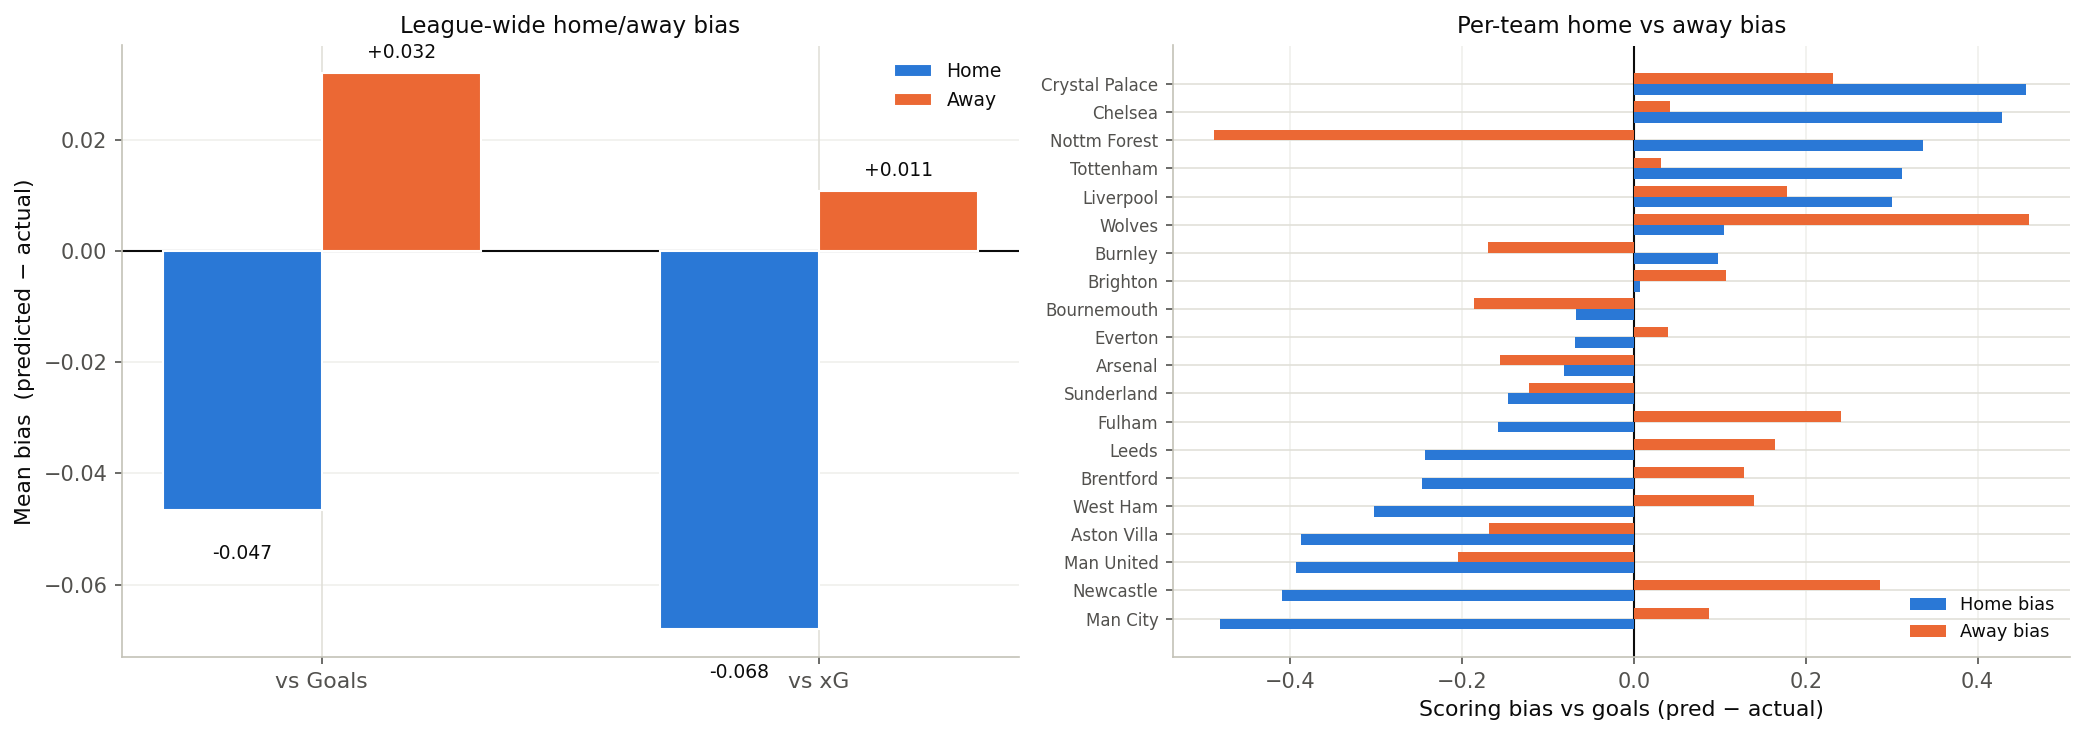

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bias_data = pd.DataFrame({
    'Home': [match['home_bias'].mean(), match['home_xg_bias'].mean()],
    'Away': [match['away_bias'].mean(), match['away_xg_bias'].mean()],
}, index=['vs Goals', 'vs xG'])

x = np.arange(len(bias_data.index))
width = 0.32

ax = axes[0]
b1 = ax.bar(x - width/2, bias_data['Home'], width, label='Home', color=C_XG, edgecolor='white', zorder=3)
b2 = ax.bar(x + width/2, bias_data['Away'], width, label='Away', color=C_GOALS, edgecolor='white', zorder=3)
ax.axhline(0, color=C_INK, lw=1)
for bars in (b1, b2):
    for bar in bars:
        v = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, v + (0.002 if v >= 0 else -0.006),
                 f'{v:+.3f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(bias_data.index, fontsize=10.5)
ax.set_ylabel('Mean bias  (predicted − actual)', fontsize=10.5)
ax.set_title('League-wide home/away bias', fontsize=11)
ax.legend(fontsize=9, frameon=False)

ax2 = axes[1]
home_bias_team = match.groupby('home_team')['home_bias'].mean().sort_values()
away_bias_team = match.groupby('away_team')['away_bias'].mean().reindex(home_bias_team.index)
y = np.arange(len(home_bias_team))
ax2.barh(y - 0.19, home_bias_team.values, height=0.38, color=C_XG, label='Home bias', zorder=3)
ax2.barh(y + 0.19, away_bias_team.values, height=0.38, color=C_GOALS, label='Away bias', zorder=3)
ax2.axvline(0, color=C_INK, lw=1)
ax2.set_yticks(y); ax2.set_yticklabels(home_bias_team.index, fontsize=8)
ax2.set_xlabel('Scoring bias vs goals (pred − actual)', fontsize=10.5)
ax2.set_title('Per-team home vs away bias', fontsize=11)
ax2.legend(fontsize=8.5, frameon=False, loc='lower right')

for ax_ in axes:
    ax_.grid(axis='x' if ax_ is axes[1] else 'y', alpha=0.5)
    for spine in ['top', 'right']:
        ax_.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / '02_home_away_bias.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Accuracy Over Time (by Round)

Each round is a chronological batch of walk-forward predictions (see note above —
not always a full 10-match gameweek). Tracking MAE round-by-round shows whether
accuracy is stable, improving as the model sees more of the season, or degrading.

In [22]:
def round_agg(g):
    mae_g = pd.concat([g['home_error'], g['away_error']]).abs().mean()
    mae_x = pd.concat([g['home_xg_bias'].abs(), g['away_xg_bias'].abs()]).mean()
    return pd.Series({
        'matches':        len(g),
        'mae_goals':      mae_g,
        'mae_xg':         mae_x,
        'total_actual':   g['total_actual'].mean(),
        'total_xg':       g['total_xg'].mean(),
        'total_pred':     g['total_pred'].mean(),
    })

round_acc = match.groupby('round').apply(round_agg, include_groups=False).reset_index()
round_acc['mae_goals_roll'] = round_acc['mae_goals'].rolling(5, min_periods=3).mean()
round_acc['mae_xg_roll']    = round_acc['mae_xg'].rolling(5, min_periods=3).mean()

print(round_acc.round(3).to_string(index=False))

 round  matches  mae_goals  mae_xg  total_actual  total_xg  total_pred  mae_goals_roll  mae_xg_roll
     6     10.0      0.861   0.557         3.300     2.984       2.894             NaN          NaN
     7     10.0      0.605   0.575         2.500     2.487       2.886             NaN          NaN
     8     10.0      0.940   0.683         2.700     3.079       2.805           0.802        0.605
     9     10.0      0.915   0.612         3.200     2.694       2.821           0.831        0.607
    10     10.0      0.785   0.746         2.700     2.503       2.834           0.821        0.635
    11     10.0      1.083   0.702         3.300     2.590       2.811           0.866        0.664
    12     10.0      0.815   0.674         2.700     3.091       2.836           0.908        0.683
    13     10.0      0.835   0.510         3.200     2.676       2.835           0.887        0.649
    14     10.0      1.174   0.602         3.300     2.594       2.806           0.938        0.647


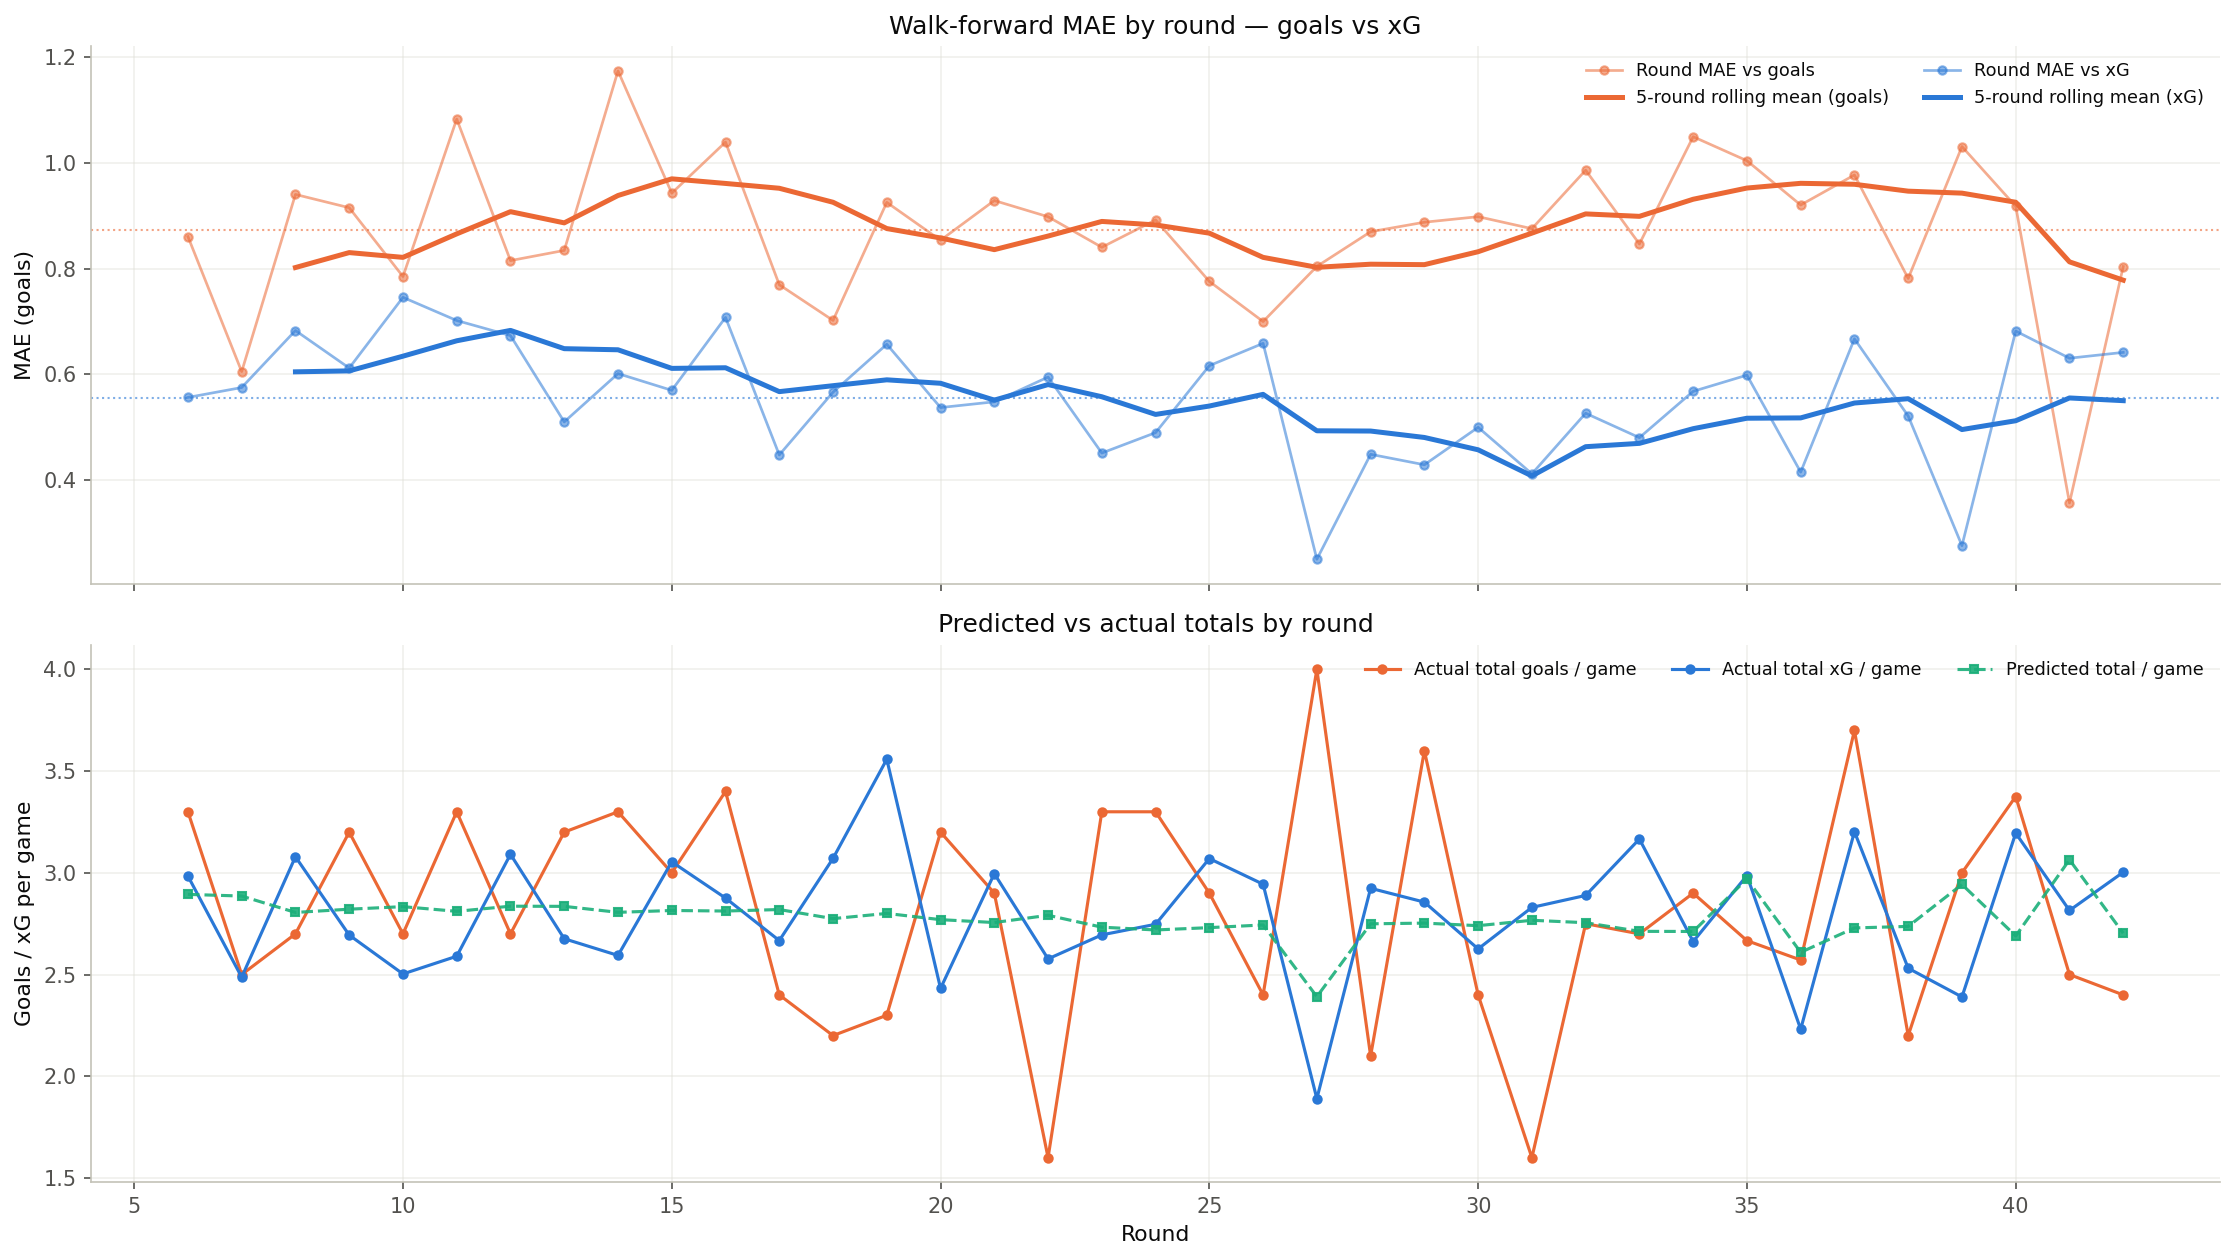

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8.5), sharex=True)

ax = axes[0]
ax.plot(round_acc['round'], round_acc['mae_goals'], 'o-', color=C_GOALS, lw=1.3, markersize=4,
        alpha=0.55, label='Round MAE vs goals')
ax.plot(round_acc['round'], round_acc['mae_goals_roll'], '-', color=C_GOALS, lw=2.4,
        label='5-round rolling mean (goals)')
ax.plot(round_acc['round'], round_acc['mae_xg'], 'o-', color=C_XG, lw=1.3, markersize=4,
        alpha=0.55, label='Round MAE vs xG')
ax.plot(round_acc['round'], round_acc['mae_xg_roll'], '-', color=C_XG, lw=2.4,
        label='5-round rolling mean (xG)')
ax.axhline(round_acc['mae_goals'].mean(), color=C_GOALS, linestyle=':', lw=1, alpha=0.6)
ax.axhline(round_acc['mae_xg'].mean(), color=C_XG, linestyle=':', lw=1, alpha=0.6)
ax.set_ylabel('MAE (goals)', fontsize=10.5)
ax.set_title('Walk-forward MAE by round — goals vs xG', fontsize=12)
ax.legend(fontsize=8.5, frameon=False, ncol=2)

ax2 = axes[1]
ax2.plot(round_acc['round'], round_acc['total_actual'], 'o-', color=C_GOALS, lw=1.5, markersize=4,
          label='Actual total goals / game')
ax2.plot(round_acc['round'], round_acc['total_xg'], 'o-', color=C_XG, lw=1.5, markersize=4,
          label='Actual total xG / game')
ax2.plot(round_acc['round'], round_acc['total_pred'], 's--', color=C_PRED, lw=1.5, markersize=4,
          alpha=0.9, label='Predicted total / game')
ax2.set_xlabel('Round', fontsize=10.5)
ax2.set_ylabel('Goals / xG per game', fontsize=10.5)
ax2.set_title('Predicted vs actual totals by round', fontsize=12)
ax2.legend(fontsize=8.5, frameon=False, ncol=3)

for ax_ in axes:
    ax_.grid(alpha=0.5)
    for spine in ['top', 'right']:
        ax_.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / '03_accuracy_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Team-by-Team Analysis — Who Gets Over/Under-Predicted

In [24]:
home_s = match[['home_team','home_predicted','home_actual','home_xg',
                 'away_predicted','away_actual','away_xg']].rename(columns={
    'home_team':'team','home_predicted':'sc_pred','home_actual':'sc_actual','home_xg':'sc_xg',
    'away_predicted':'co_pred','away_actual':'co_actual','away_xg':'co_xg'})
away_s = match[['away_team','away_predicted','away_actual','away_xg',
                 'home_predicted','home_actual','home_xg']].rename(columns={
    'away_team':'team','away_predicted':'sc_pred','away_actual':'sc_actual','away_xg':'sc_xg',
    'home_predicted':'co_pred','home_actual':'co_actual','home_xg':'co_xg'})
combined = pd.concat([home_s, away_s], ignore_index=True)

combined['sc_bias']    = combined['sc_pred'] - combined['sc_actual']   # goals bias, scoring side
combined['sc_xg_bias'] = combined['sc_pred'] - combined['sc_xg']       # xG bias, scoring side
combined['xg_luck']    = combined['sc_actual'] - combined['sc_xg']     # goals over/under xG
combined['co_bias']    = combined['co_pred'] - combined['co_actual']   # goals bias, conceding side
combined['co_xg_bias'] = combined['co_pred'] - combined['co_xg']       # xG bias, conceding side

team_stats = combined.groupby('team').agg(
    n          = ('sc_actual', 'count'),
    sc_actual  = ('sc_actual', 'mean'),
    sc_xg      = ('sc_xg',     'mean'),
    sc_pred    = ('sc_pred',   'mean'),
    sc_bias    = ('sc_bias',   'mean'),
    sc_xg_bias = ('sc_xg_bias','mean'),
    xg_luck    = ('xg_luck',   'mean'),
    co_actual  = ('co_actual', 'mean'),
    co_xg      = ('co_xg',     'mean'),
    co_pred    = ('co_pred',   'mean'),
    co_bias    = ('co_bias',   'mean'),
    co_xg_bias = ('co_xg_bias','mean'),
).round(3).sort_values('sc_xg', ascending=False)

print('sc = scoring side (attack: goals/xG for),  co = conceding side (defence: goals/xG against)')
print('bias = predicted − actual   (positive = model over-predicts, negative = under-predicts)')
print()
team_stats

sc = scoring side (attack: goals/xG for),  co = conceding side (defence: goals/xG against)
bias = predicted − actual   (positive = model over-predicts, negative = under-predicts)



,n,sc_actual,sc_xg,sc_pred,sc_bias,sc_xg_bias,xg_luck,co_actual,co_xg,co_pred,co_bias,co_xg_bias
team,,,,,,,,,,,,
Man City,33,2.061,1.876,1.855,-0.206,-0.022,0.184,0.909,1.153,1.141,0.231,-0.012
Chelsea,33,1.455,1.762,1.695,0.241,-0.067,-0.308,1.424,1.413,1.322,-0.102,-0.091
Arsenal,33,1.848,1.758,1.729,-0.120,-0.029,0.091,0.758,0.759,0.862,0.104,0.103
Bournemouth,33,1.576,1.680,1.447,-0.129,-0.233,-0.104,1.485,1.612,1.442,-0.043,-0.171
Man United,33,1.909,1.673,1.613,-0.296,-0.061,0.236,1.273,1.249,1.399,0.126,0.149
Brentford,33,1.485,1.646,1.420,-0.065,-0.226,-0.161,1.273,1.442,1.329,0.056,-0.113
Liverpool,33,1.576,1.626,1.813,0.237,0.187,-0.051,1.455,1.316,1.196,-0.259,-0.120
Newcastle,33,1.515,1.592,1.443,-0.072,-0.150,-0.077,1.576,1.478,1.249,-0.327,-0.230
Leeds,33,1.364,1.515,1.319,-0.045,-0.196,-0.151,1.485,1.482,1.469,-0.015,-0.012


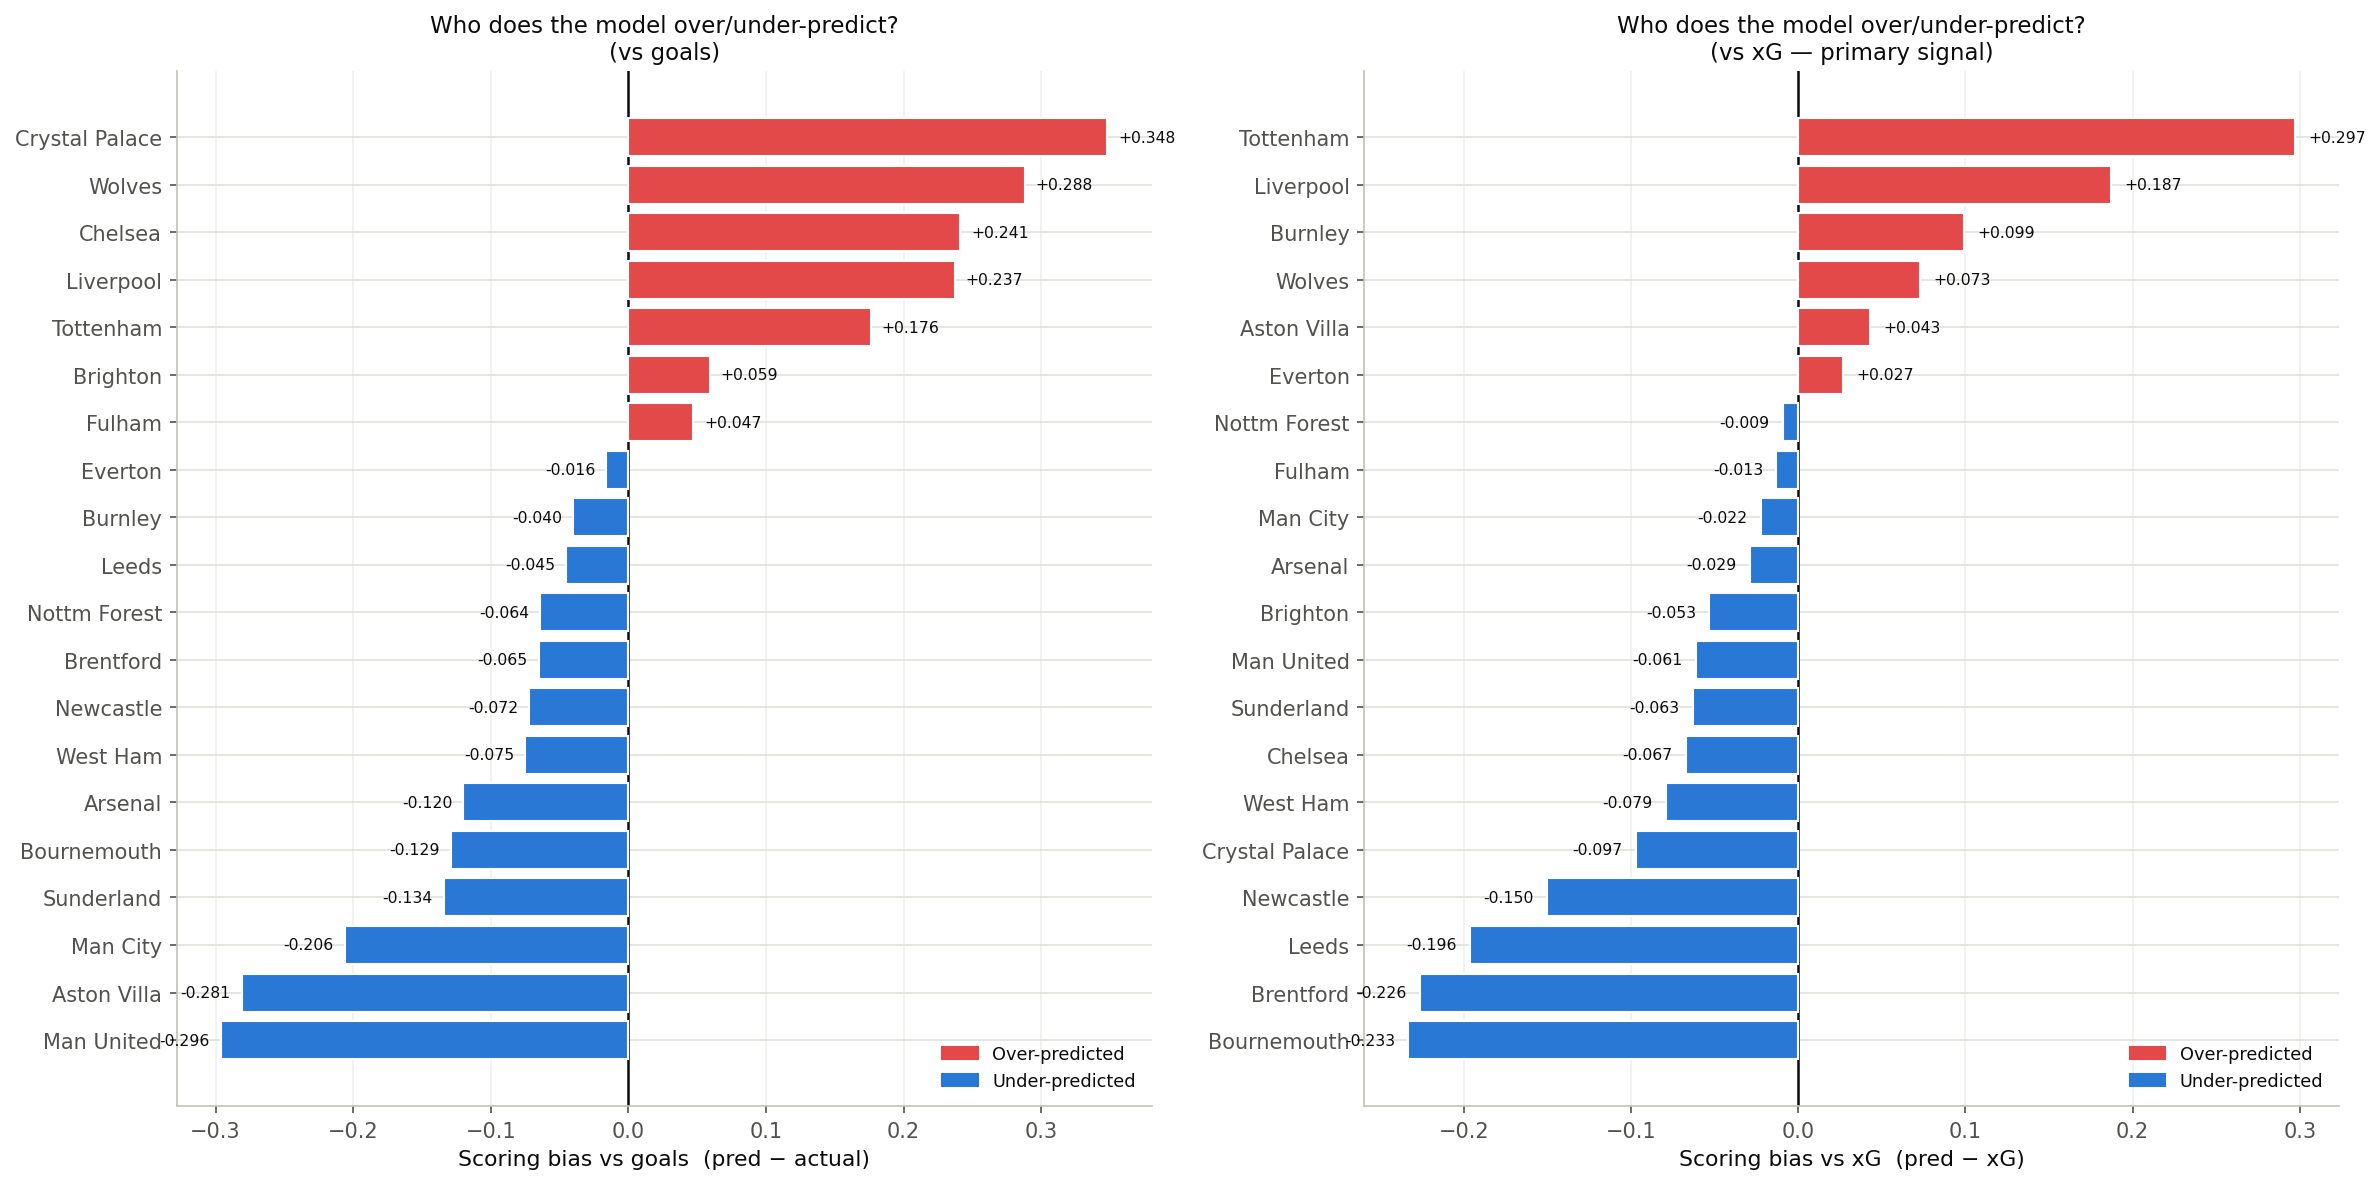

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

ts_goals = team_stats.sort_values('sc_bias')
ts_xg    = team_stats.sort_values('sc_xg_bias')

ax = axes[0]
colors_g = [C_OVER if b > 0 else C_UNDER for b in ts_goals['sc_bias']]
bars = ax.barh(ts_goals.index, ts_goals['sc_bias'], color=colors_g, edgecolor='white', zorder=3)
ax.axvline(0, color=C_INK, lw=1.2)
for bar, val in zip(bars, ts_goals['sc_bias']):
    ax.text(val + (0.008 if val >= 0 else -0.008), bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=7.5)
ax.set_xlabel('Scoring bias vs goals  (pred − actual)', fontsize=10.5)
ax.set_title('Who does the model over/under-predict?\n(vs goals)', fontsize=11)
ax.legend(handles=[mpatches.Patch(color=C_OVER, label='Over-predicted'),
                    mpatches.Patch(color=C_UNDER, label='Under-predicted')],
          fontsize=8.5, loc='lower right', frameon=False)

ax2 = axes[1]
colors_x = [C_OVER if b > 0 else C_UNDER for b in ts_xg['sc_xg_bias']]
bars2 = ax2.barh(ts_xg.index, ts_xg['sc_xg_bias'], color=colors_x, edgecolor='white', zorder=3)
ax2.axvline(0, color=C_INK, lw=1.2)
for bar, val in zip(bars2, ts_xg['sc_xg_bias']):
    ax2.text(val + (0.008 if val >= 0 else -0.008), bar.get_y() + bar.get_height()/2,
             f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=7.5)
ax2.set_xlabel('Scoring bias vs xG  (pred − xG)', fontsize=10.5)
ax2.set_title('Who does the model over/under-predict?\n(vs xG — primary signal)', fontsize=11)
ax2.legend(handles=[mpatches.Patch(color=C_OVER, label='Over-predicted'),
                     mpatches.Patch(color=C_UNDER, label='Under-predicted')],
           fontsize=8.5, loc='lower right', frameon=False)

for ax_ in axes:
    ax_.grid(axis='x', alpha=0.5)
    for spine in ['top', 'right']:
        ax_.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / '04_team_bias.png', dpi=150, bbox_inches='tight')
plt.show()

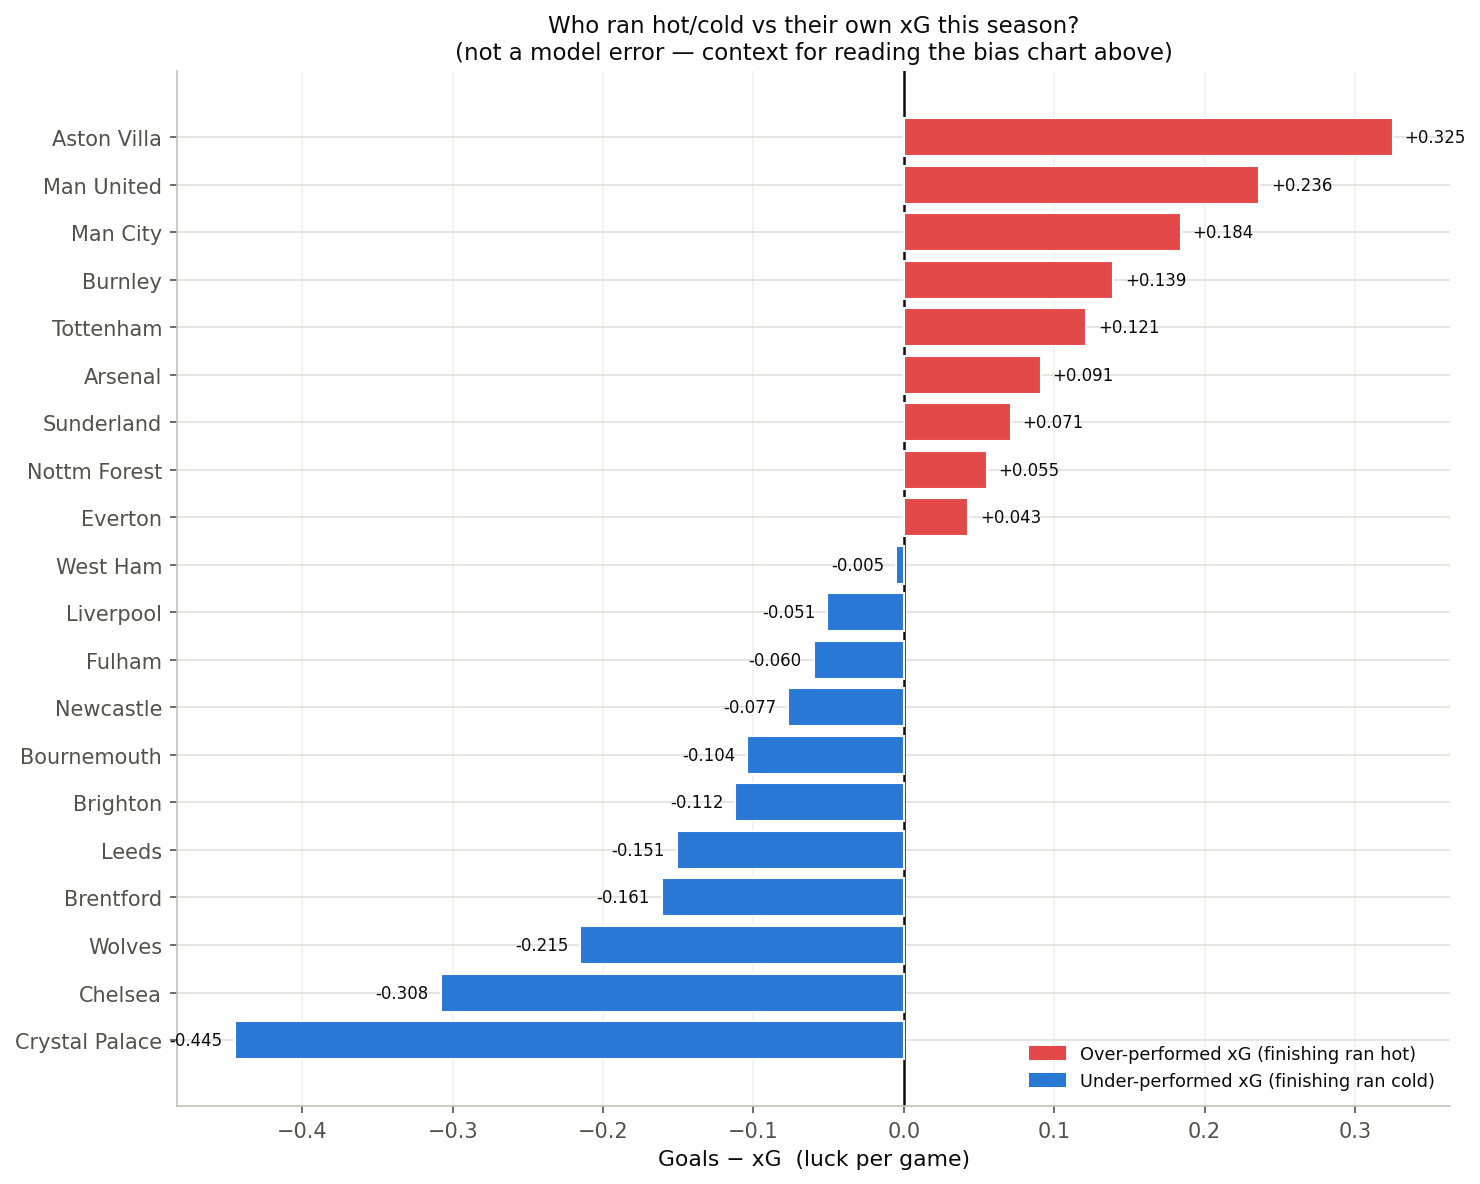

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))

ts_luck = team_stats.sort_values('xg_luck')
colors_l = [C_OVER if b > 0 else C_UNDER for b in ts_luck['xg_luck']]
bars = ax.barh(ts_luck.index, ts_luck['xg_luck'], color=colors_l, edgecolor='white', zorder=3)
ax.axvline(0, color=C_INK, lw=1.2)
for bar, val in zip(bars, ts_luck['xg_luck']):
    ax.text(val + (0.008 if val >= 0 else -0.008), bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
ax.set_xlabel('Goals − xG  (luck per game)', fontsize=10.5)
ax.set_title('Who ran hot/cold vs their own xG this season?\n(not a model error — context for reading the bias chart above)', fontsize=11)
ax.legend(handles=[mpatches.Patch(color=C_OVER, label='Over-performed xG (finishing ran hot)'),
                    mpatches.Patch(color=C_UNDER, label='Under-performed xG (finishing ran cold)')],
          fontsize=8.5, loc='lower right', frameon=False)
ax.grid(axis='x', alpha=0.5)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / '05_team_xg_luck.png', dpi=150, bbox_inches='tight')
plt.show()

### Attack vs Defence — Which Half of Each Team's Game Does the Model Get Wrong?

Two separate biases can cancel out in the overall scoring-bias number: a team can
be overrated going forward and underrated at the back at the same time. This plots
each team on **attack bias** (x) vs **defence bias** (y) — both signed so that
**positive = model rates that unit better than it actually is**. A team in the
top-right is overrated on both ends; bottom-left is underrated on both ends;
the other two corners are where the model has the shape of the team wrong even
if its overall goal difference looks fine.

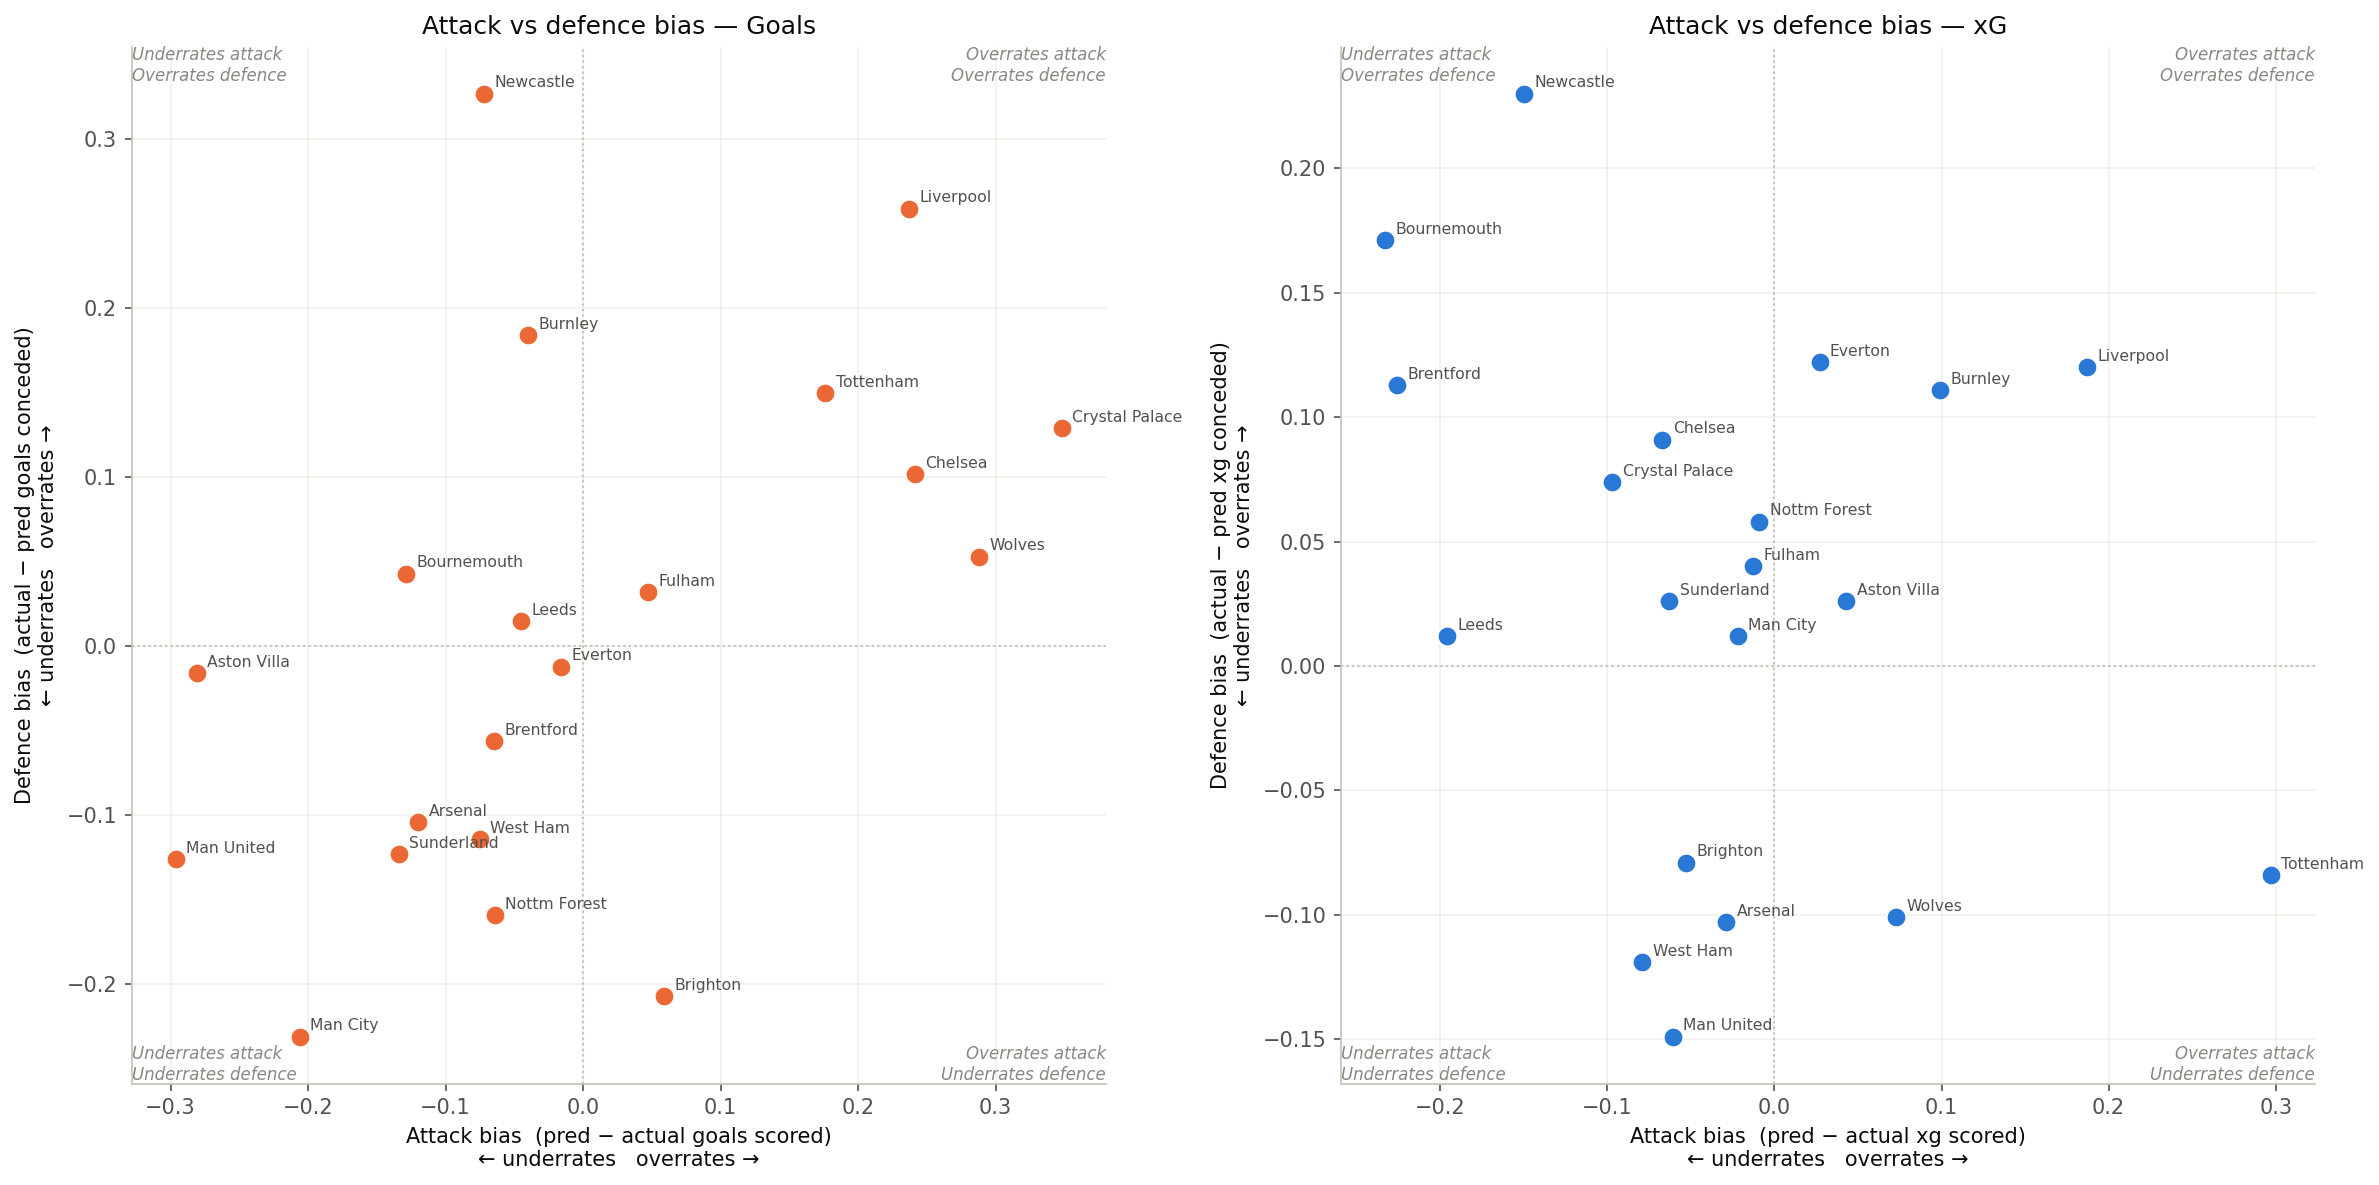

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, att_col, def_col, title, color in [
    (axes[0], 'sc_bias',    'co_bias',    'Goals', C_GOALS),
    (axes[1], 'sc_xg_bias', 'co_xg_bias', 'xG',    C_XG),
]:
    # Attack bias: pred - actual scored -> positive = model overrates attack (as-is)
    # Defence bias: flip sign of (pred - actual conceded) -> positive = model overrates defence
    #   (predicting fewer conceded than reality means the model thinks defence is better than it is)
    att_bias = team_stats[att_col]
    def_bias = -team_stats[def_col]

    ax.scatter(att_bias, def_bias, s=90, color=color, edgecolors='white', zorder=3)
    for team in team_stats.index:
        ax.annotate(team, (att_bias[team], def_bias[team]), textcoords='offset points',
                    xytext=(5, 3), fontsize=7.5, color=C_INK2)
    ax.axvline(0, color=C_AXIS, lw=1, linestyle=':')
    ax.axhline(0, color=C_AXIS, lw=1, linestyle=':')
    ax.set_xlabel(f'Attack bias  (pred − actual {title.lower()} scored)\n← underrates   overrates →', fontsize=10)
    ax.set_ylabel(f'Defence bias  (actual − pred {title.lower()} conceded)\n← underrates   overrates →', fontsize=10)
    ax.set_title(f'Attack vs defence bias — {title}', fontsize=12)

    xr = ax.get_xlim(); yr = ax.get_ylim()
    ax.text(xr[1], yr[1], 'Overrates attack\nOverrates defence', ha='right', va='top',
            fontsize=8, color=C_MUTED, style='italic')
    ax.text(xr[0], yr[1], 'Underrates attack\nOverrates defence', ha='left', va='top',
            fontsize=8, color=C_MUTED, style='italic')
    ax.text(xr[1], yr[0], 'Overrates attack\nUnderrates defence', ha='right', va='bottom',
            fontsize=8, color=C_MUTED, style='italic')
    ax.text(xr[0], yr[0], 'Underrates attack\nUnderrates defence', ha='left', va='bottom',
            fontsize=8, color=C_MUTED, style='italic')

    ax.grid(alpha=0.5)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / '07_attack_defence_bias.png', dpi=150, bbox_inches='tight')
plt.show()

### Attack & Defence — Predicted vs Actual (with Accuracy Line)

Same two units (attack, defence) but plotted directly as predicted vs actual,
each with the y = x diagonal marking a perfect prediction. Distance above the
line = model predicts more than reality; below = predicts less. This keeps the
actual scale in view (unlike the bias-only chart above), so you can see whether
a team is off by a little in absolute terms or a lot.

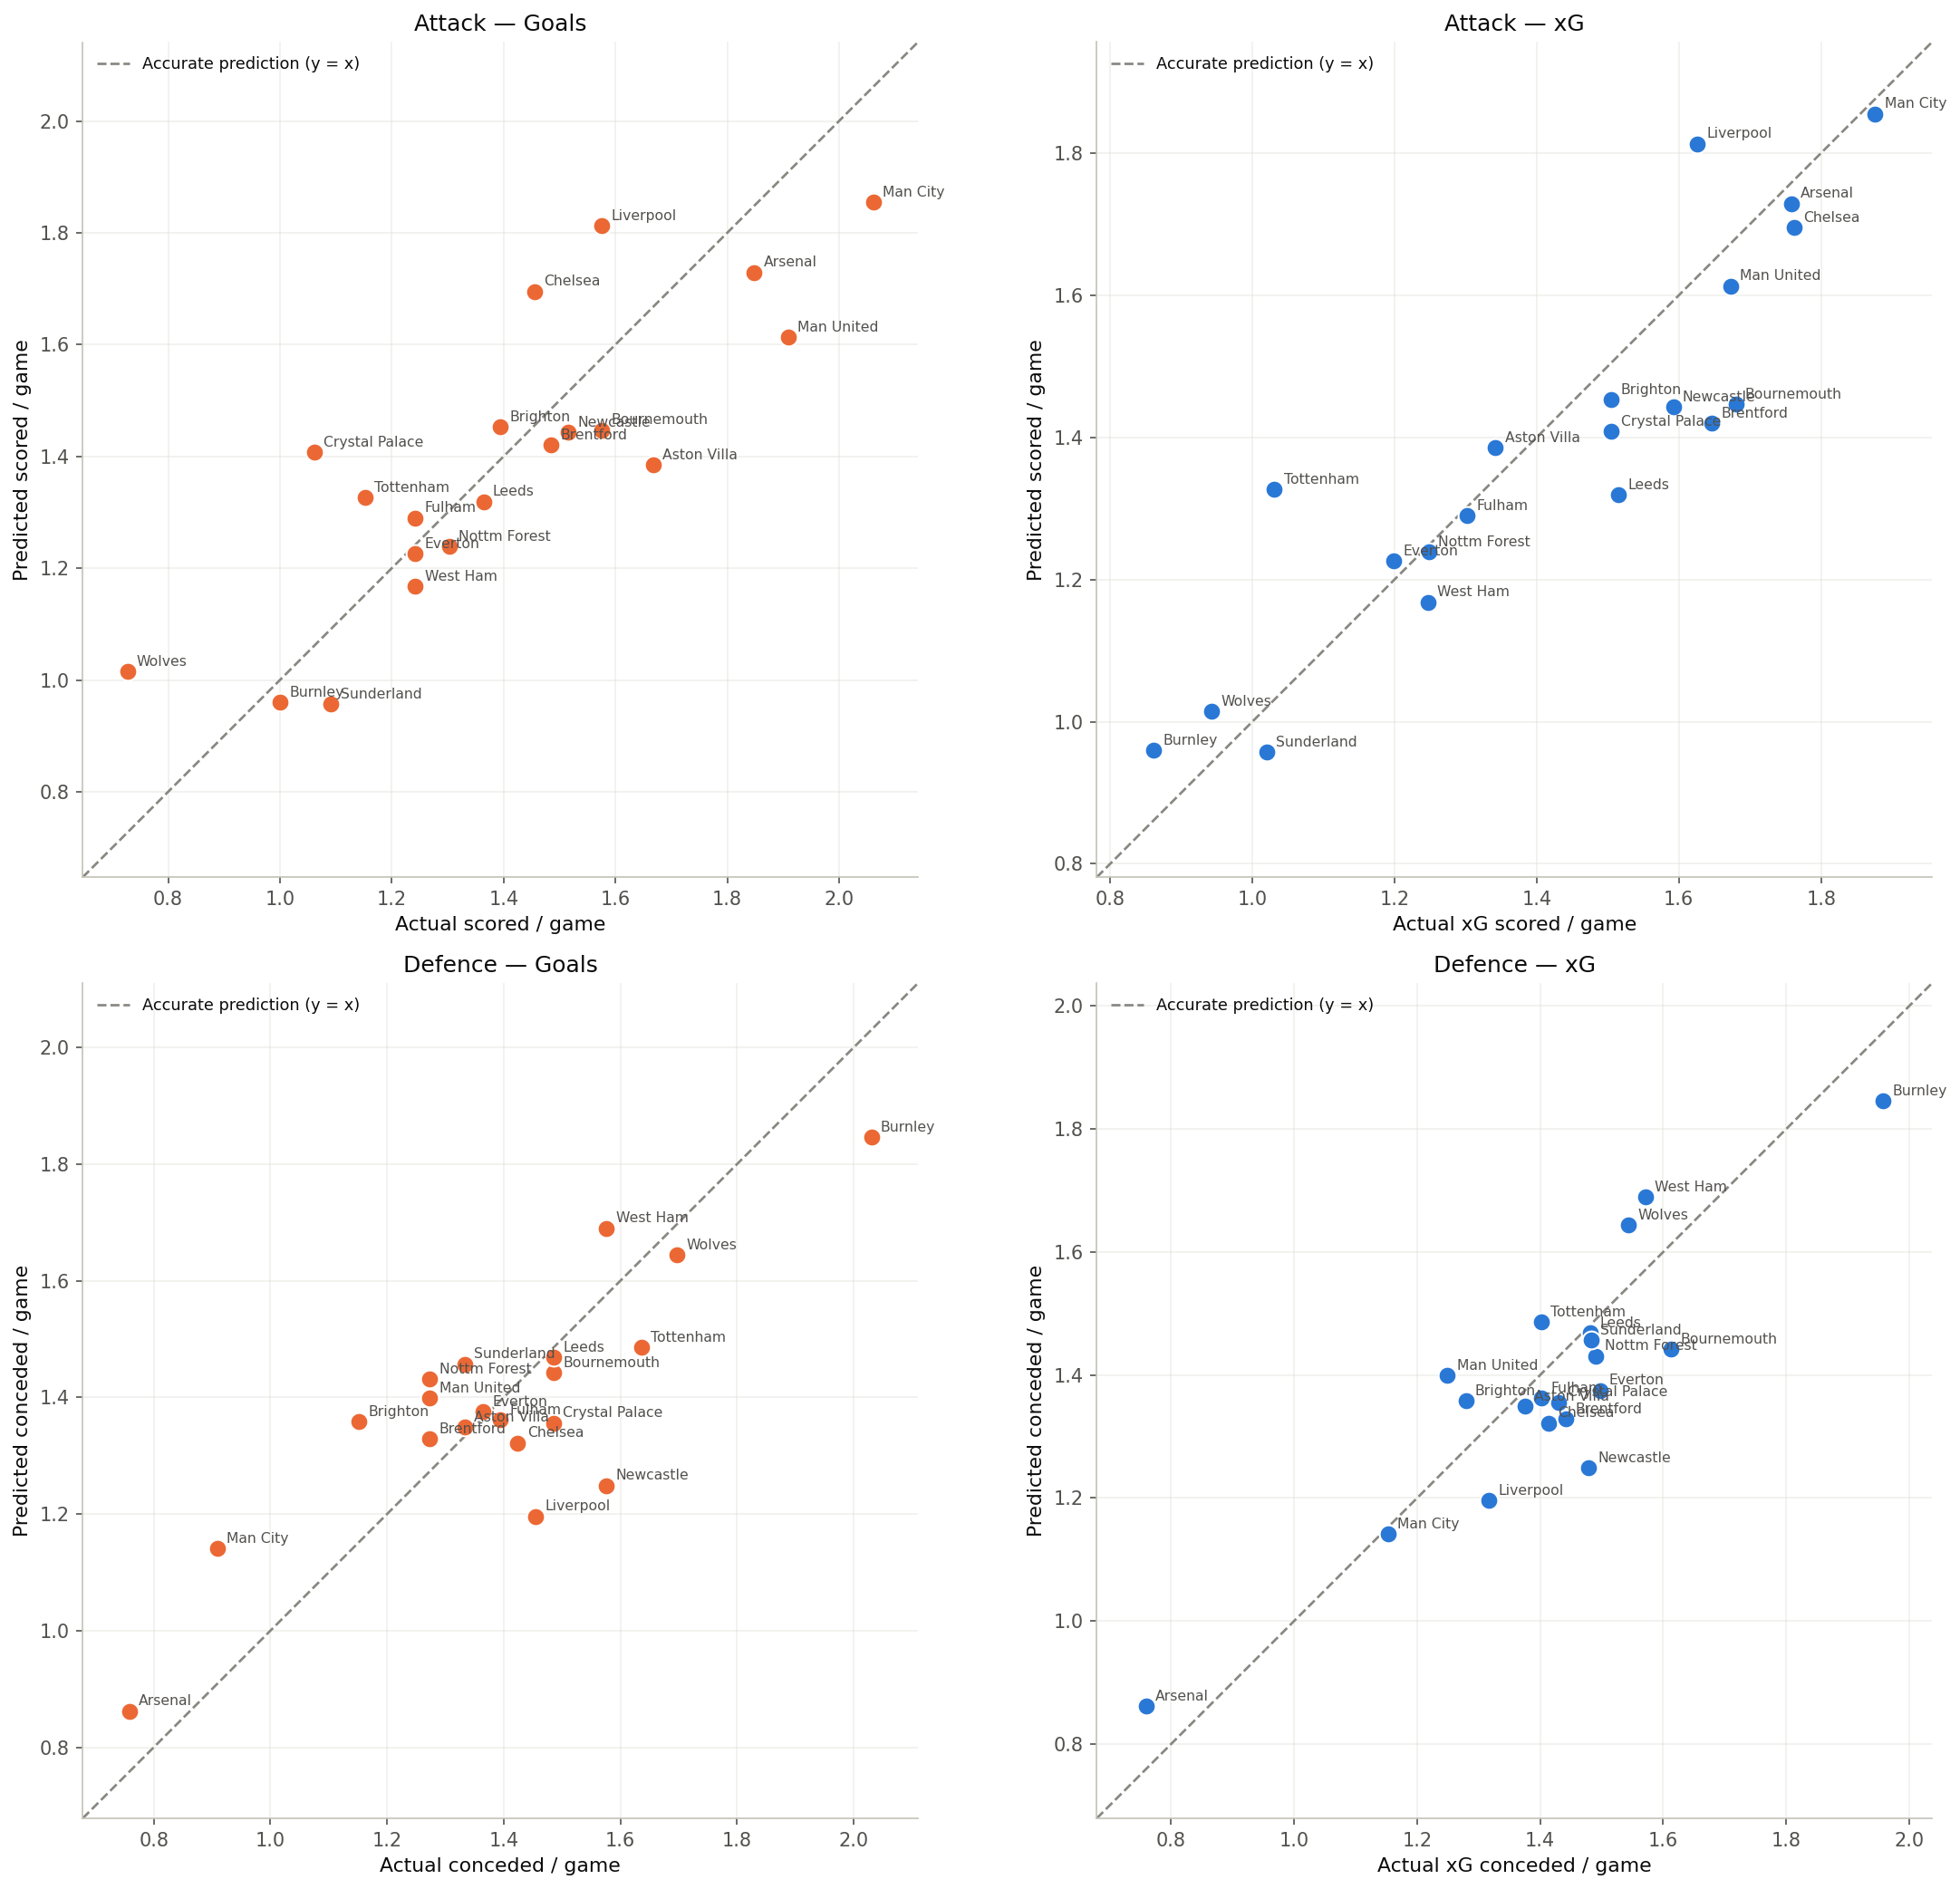

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(15, 14))

panels = [
    (axes[0, 0], 'sc_actual', 'sc_pred', 'Attack — Goals', 'Actual scored / game',   'Predicted scored / game',   C_GOALS),
    (axes[0, 1], 'sc_xg',     'sc_pred', 'Attack — xG',    'Actual xG scored / game', 'Predicted scored / game',   C_XG),
    (axes[1, 0], 'co_actual', 'co_pred', 'Defence — Goals','Actual conceded / game',  'Predicted conceded / game', C_GOALS),
    (axes[1, 1], 'co_xg',     'co_pred', 'Defence — xG',   'Actual xG conceded / game','Predicted conceded / game', C_XG),
]

for ax, x_col, y_col, title, xlabel, ylabel, color in panels:
    x = team_stats[x_col]; y = team_stats[y_col]
    ax.scatter(x, y, s=90, color=color, edgecolors='white', zorder=3)
    for team in team_stats.index:
        ax.annotate(team, (x[team], y[team]), textcoords='offset points',
                    xytext=(5, 3), fontsize=7.5, color=C_INK2)
    lo = min(x.min(), y.min()) - 0.08
    hi = max(x.max(), y.max()) + 0.08
    ax.plot([lo, hi], [lo, hi], '--', color=C_MUTED, lw=1.3, label='Accurate prediction (y = x)')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(xlabel, fontsize=10.5)
    ax.set_ylabel(ylabel, fontsize=10.5)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8.5, frameon=False, loc='upper left')
    ax.grid(alpha=0.5)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / '08_attack_defence_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Shrinkage Analysis

If the model systematically pulls strong attacks down and weak attacks up
toward the league mean, bias should correlate negatively with actual output —
teams that score/create a lot get under-predicted less than they should, and
teams that create little get pulled up. A negative Spearman correlation here
is the signature of overshrinkage.

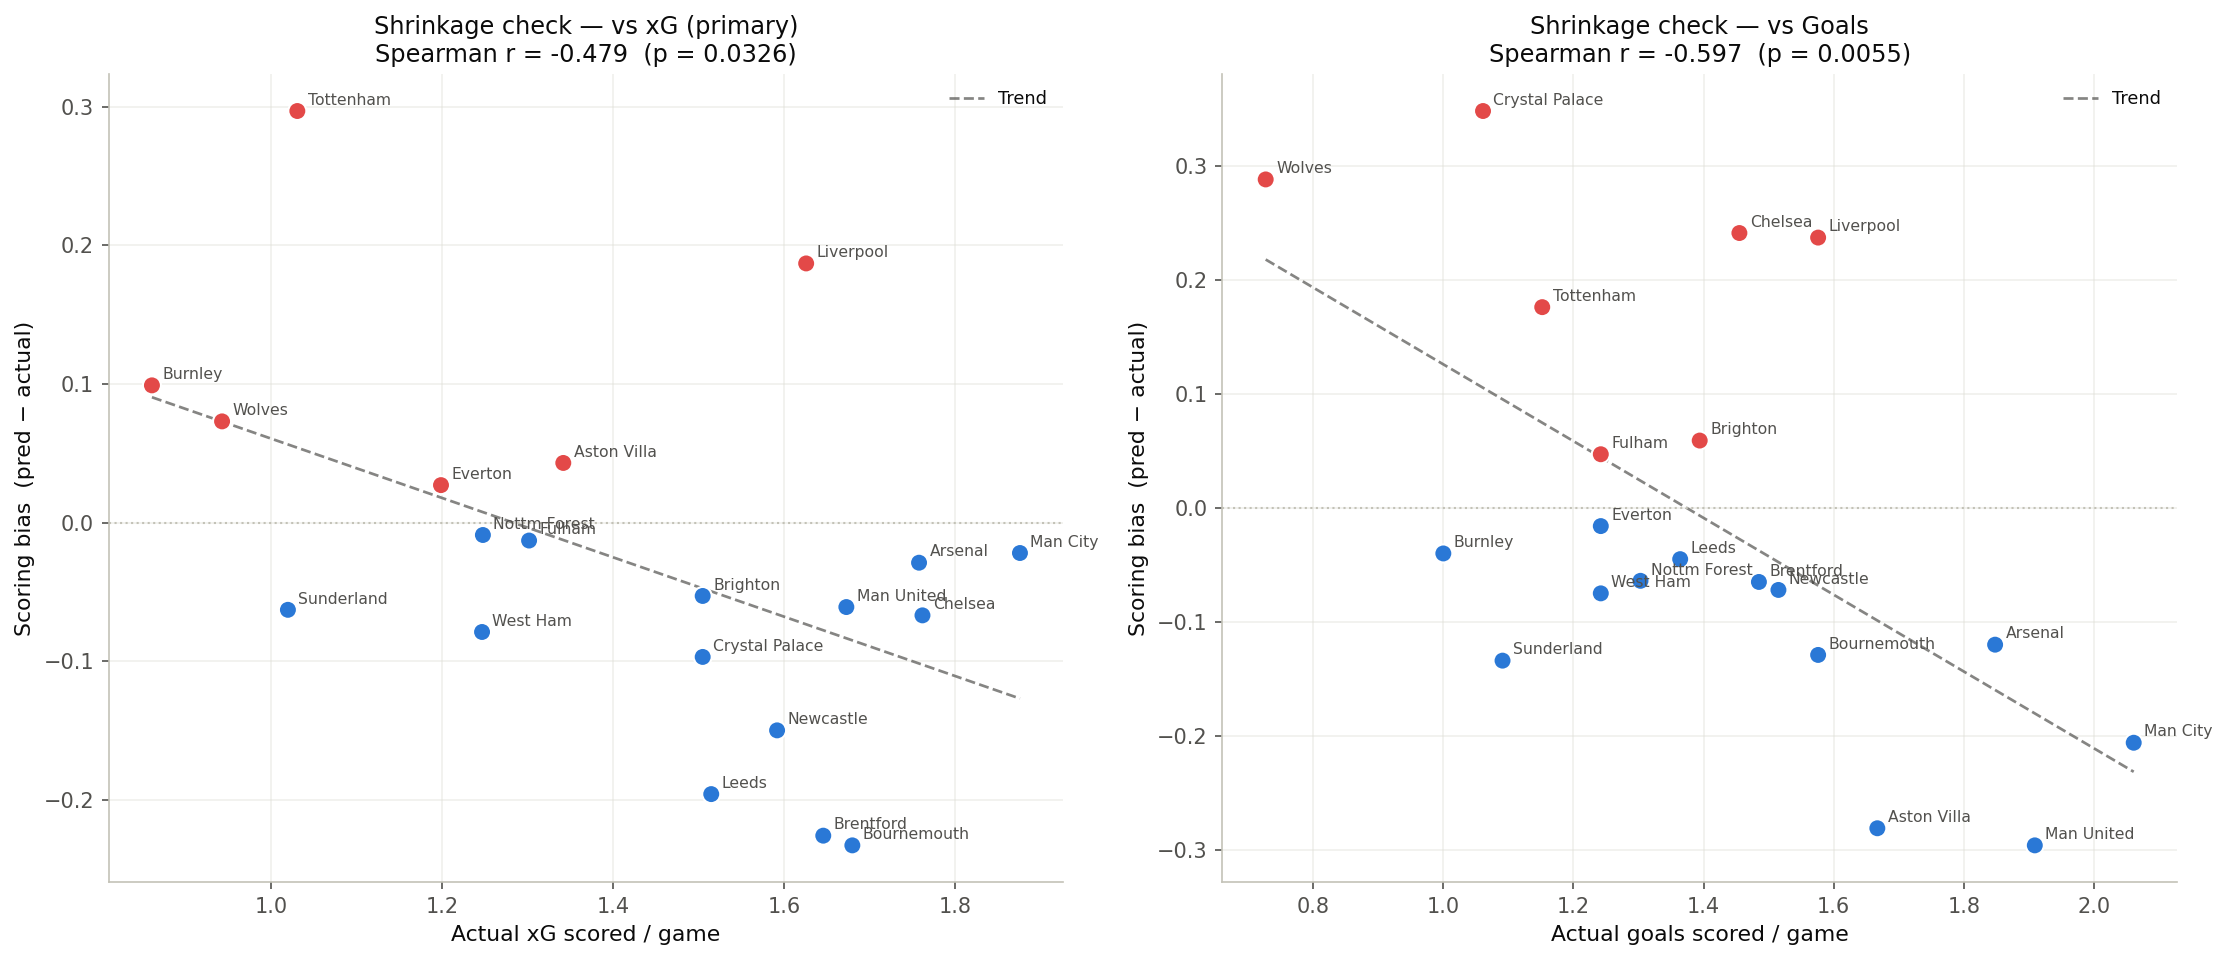

Shrinkage vs goals: Spearman r = -0.597  (p=0.0055)
Shrinkage vs xG:    Spearman r = -0.479  (p=0.0326)
Verdict: CONFIRMED — negative slope pulls strong teams down, weak teams up


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

for ax, x_col, bias_col, title, xlabel, color in [
    (axes[0], 'sc_xg',     'sc_xg_bias', 'vs xG (primary)', 'Actual xG scored / game',   C_XG),
    (axes[1], 'sc_actual', 'sc_bias',    'vs Goals',        'Actual goals scored / game', C_GOALS),
]:
    corr, pval = spearmanr(team_stats[x_col], team_stats[bias_col])
    pt_colors = [C_OVER if b > 0 else C_UNDER for b in team_stats[bias_col]]
    ax.scatter(team_stats[x_col], team_stats[bias_col], color=pt_colors, s=75,
               edgecolors='white', zorder=3)
    for team, row in team_stats.iterrows():
        ax.annotate(team, (row[x_col], row[bias_col]), textcoords='offset points',
                    xytext=(5, 3), fontsize=7.5, color=C_INK2)
    m, b = np.polyfit(team_stats[x_col], team_stats[bias_col], 1)
    xs = np.linspace(team_stats[x_col].min(), team_stats[x_col].max(), 100)
    ax.plot(xs, m*xs + b, '--', color=C_INK2, alpha=0.7, lw=1.3, label='Trend')
    ax.axhline(0, color=C_AXIS, lw=1, linestyle=':')
    ax.set_xlabel(xlabel, fontsize=10.5)
    ax.set_ylabel('Scoring bias  (pred − actual)', fontsize=10.5)
    ax.set_title(f'Shrinkage check — {title}\nSpearman r = {corr:.3f}  (p = {pval:.4f})', fontsize=11.5)
    ax.legend(fontsize=8.5, frameon=False)
    ax.grid(alpha=0.5)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / '06_shrinkage.png', dpi=150, bbox_inches='tight')
plt.show()

corr_g, pval_g = spearmanr(team_stats['sc_actual'], team_stats['sc_bias'])
corr_x, pval_x = spearmanr(team_stats['sc_xg'],     team_stats['sc_xg_bias'])
verdict = 'CONFIRMED — negative slope pulls strong teams down, weak teams up' if (corr_x < 0 and pval_x < 0.05) \
          else ('Suggestive but not significant' if corr_x < 0 else 'Not present')
print(f'Shrinkage vs goals: Spearman r = {corr_g:+.3f}  (p={pval_g:.4f})')
print(f'Shrinkage vs xG:    Spearman r = {corr_x:+.3f}  (p={pval_x:.4f})')
print(f'Verdict: {verdict}')

In [30]:
std_table = pd.DataFrame({
    'Side':               ['Home', 'Away', 'Total'],
    'Actual goals std':   [match['home_actual'].std(),    match['away_actual'].std(),    match['total_actual'].std()],
    'Actual xG std':      [match['home_xg'].std(),         match['away_xg'].std(),         match['total_xg'].std()],
    'Predicted std':      [match['home_predicted'].std(),  match['away_predicted'].std(),  match['total_pred'].std()],
}).round(4)
std_table['Compression vs goals'] = (std_table['Actual goals std'] / std_table['Predicted std']).round(2)
std_table['Compression vs xG']    = (std_table['Actual xG std']    / std_table['Predicted std']).round(2)

print('Variance compression — a ratio > 1 means predictions are narrower than reality:')
print(std_table.to_string(index=False))
print()
print('This is a second, independent lens on shrinkage: even against xG (which already has')
print('lower variance than goals), predictions are compressed further — consistent with priors')
print('that are too tight rather than pure Poisson noise.')
std_table

Variance compression — a ratio > 1 means predictions are narrower than reality:
 Side  Actual goals std  Actual xG std  Predicted std  Compression vs goals  Compression vs xG
 Home            1.1640         0.7976         0.3564                  3.27               2.24
 Away            1.0613         0.7308         0.3014                  3.52               2.42
Total            1.5638         1.0082         0.2740                  5.71               3.68

This is a second, independent lens on shrinkage: even against xG (which already has
lower variance than goals), predictions are compressed further — consistent with priors
that are too tight rather than pure Poisson noise.


,Side,Actual goals std,Actual xG std,Predicted std,Compression vs goals,Compression vs xG
0,Home,1.1640,0.7976,0.3564,3.27,2.24
1,Away,1.0613,0.7308,0.3014,3.52,2.42
2,Total,1.5638,1.0082,0.2740,5.71,3.68


## Summary — Key Findings

In [31]:
print('=== 2025-26 POST-MORTEM SUMMARY ===')
print()
print('OVERALL')
print(f'  MAE vs goals (skill + luck):  {mae_goals:.4f}')
print(f'  MAE vs xG (skill only):       {mae_xg:.4f}')
print(f'  Irreducible Poisson noise:    {noise:.4f}   ({(mae_goals-mae_xg)/mae_goals:.0%} of goals-MAE is unforecastable)')
print(f'  Home bias:  goals {match["home_bias"].mean():+.4f}  |  xG {match["home_xg_bias"].mean():+.4f}')
print(f'  Away bias:  goals {match["away_bias"].mean():+.4f}  |  xG {match["away_xg_bias"].mean():+.4f}')
print()
print('ACCURACY OVER TIME')
print(f'  Round MAE range (goals): {round_acc["mae_goals"].min():.3f} – {round_acc["mae_goals"].max():.3f}')
print(f'  Round MAE range (xG):    {round_acc["mae_xg"].min():.3f} – {round_acc["mae_xg"].max():.3f}')
print()
print('TEAM-BY-TEAM')
most_over_xg  = team_stats['sc_xg_bias'].idxmax()
most_under_xg = team_stats['sc_xg_bias'].idxmin()
print(f'  Most over-predicted vs xG:  {most_over_xg}  ({team_stats.loc[most_over_xg, "sc_xg_bias"]:+.3f})')
print(f'  Most under-predicted vs xG: {most_under_xg}  ({team_stats.loc[most_under_xg, "sc_xg_bias"]:+.3f})')
print()
print('SHRINKAGE')
print(f'  Spearman r (bias vs xG level):    {corr_x:+.3f}  (p={pval_x:.4f})')
print(f'  Spearman r (bias vs goals level): {corr_g:+.3f}  (p={pval_g:.4f})')
print(f'  Compression ratio (total, vs xG):    {xg_std_total/pred_std_total:.2f}x')
print(f'  Compression ratio (total, vs goals):  {goals_std_total/pred_std_total:.2f}x')

=== 2025-26 POST-MORTEM SUMMARY ===

OVERALL
  MAE vs goals (skill + luck):  0.8788
  MAE vs xG (skill only):       0.5695
  Irreducible Poisson noise:    0.7899   (35% of goals-MAE is unforecastable)
  Home bias:  goals -0.0467  |  xG -0.0680
  Away bias:  goals +0.0319  |  xG +0.0108

ACCURACY OVER TIME
  Round MAE range (goals): 0.357 – 1.174
  Round MAE range (xG):    0.251 – 0.746

TEAM-BY-TEAM
  Most over-predicted vs xG:  Tottenham  (+0.297)
  Most under-predicted vs xG: Bournemouth  (-0.233)

SHRINKAGE
  Spearman r (bias vs xG level):    -0.479  (p=0.0326)
  Spearman r (bias vs goals level): -0.597  (p=0.0055)
  Compression ratio (total, vs xG):    3.68x
  Compression ratio (total, vs goals):  5.71x


## Data Export — Tables to Copy/Paste

The underlying tables behind every chart above, printed as CSV so you can
copy straight out of the cell output. Each is also saved to `outputs/*.csv`.

In [32]:
export_tables = {
    'overall_summary.csv':        overall,
    'round_accuracy.csv':         round_acc.round(4),
    'team_stats.csv':             team_stats.reset_index(),
    'variance_compression.csv':   std_table,
}

for fname, tbl in export_tables.items():
    tbl.to_csv(OUT_DIR / fname, index=False)
    print(f'───────────────────────────────────────────  {fname}  ───────────────────────────────────────────')
    print(tbl.to_csv(index=False))
    print()

───────────────────────────────────────────  overall_summary.csv  ───────────────────────────────────────────
Metric,Value
MAE — predicted vs goals (skill + luck),0.8788
MAE — predicted vs xG (skill only),0.5695
Irreducible noise  |goals − xG|,0.7899
MAE gap explained by noise,35%
,
Home bias vs goals  (pred − actual),-0.0467
Away bias vs goals  (pred − actual),0.0319
Home bias vs xG     (pred − xG),-0.068
Away bias vs xG     (pred − xG),0.0108
,
Std dev — predicted total / game,0.274
Std dev — actual goals total / game,1.5638
Std dev — actual xG total / game,1.0082
Compression ratio  (goals σ / pred σ),5.71
Compression ratio  (xG σ / pred σ),3.68


───────────────────────────────────────────  round_accuracy.csv  ───────────────────────────────────────────
round,matches,mae_goals,mae_xg,total_actual,total_xg,total_pred,mae_goals_roll,mae_xg_roll
6,10.0,0.8608,0.5566,3.3,2.984,2.894,,
7,10.0,0.6054,0.5753,2.5,2.487,2.8858,,
8,10.0,0.9405,0.6831,2.7,3.079,2.8052,0.8022,0.605
9,10.0,0.915